# UBX Track Plotter
Parses `.ubx` log files and plots the latitude/longitude track.
Uses the same NAV-PVT + NAV-HPPOSLLH merge logic as `v3_ubx_parser.py`.

**Requirements**
```
pip install pyubx2 pandas matplotlib folium
```

In [13]:
import glob
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

try:
    import folium
    HAS_FOLIUM = True
except ImportError:
    HAS_FOLIUM = False
    print("folium not installed — interactive map will be skipped. Run: pip install folium")

from pyubx2 import UBXReader

## 1 — Select file
Set `UBX_FILE` to the path of your `.ubx` log, or leave it as `None` to auto-detect the most recent one in this directory.

In [14]:
UBX_FILE = 'april_28_walking_around_courtyard.ubx'   # e.g. "../data/dataLog00029.ubx"

if UBX_FILE is None:
    candidates = sorted(glob.glob("../**/*.ubx", recursive=True) + glob.glob("*.ubx"))
    if not candidates:
        sys.exit("No .ubx files found. Set UBX_FILE manually.")
    UBX_FILE = candidates[-1]   # most recent by name

print(f"Parsing: {UBX_FILE}")

Parsing: april_28_walking_around_courtyard.ubx


## 2 — Parse

In [15]:
def parse_ubx(path):
    """Returns a DataFrame of position records, one row per epoch.

    pyubx2 (>=1.2.x) auto-scales lat/lon to degrees (float), but leaves
    height / hAcc / vAcc as raw millimetre integers — so we use lat/lon
    as-is and divide the mm fields by 1000 to get metres.
    """
    pvt, hppos = {}, {}

    with open(path, "rb") as f:
        for _, parsed in UBXReader(f):
            if not hasattr(parsed, "identity"):
                continue
            iTOW = getattr(parsed, "iTOW", None)
            if iTOW is None:
                continue

            if parsed.identity == "NAV-PVT":
                pvt[iTOW] = dict(
                    iTOW=iTOW,
                    year=getattr(parsed, "year", 0),
                    month=getattr(parsed, "month", 0),
                    day=getattr(parsed, "day", 0),
                    hour=getattr(parsed, "hour", 0),
                    minute=getattr(parsed, "min", 0),
                    second=getattr(parsed, "sec", 0),
                    fix_type=getattr(parsed, "fixType", 0),
                    carrier_solution=getattr(parsed, "carrSoln", 0),
                    num_sv=getattr(parsed, "numSV", 0),
                    pdop=getattr(parsed, "pDOP", 0) / 100.0,
                    speed_ms=getattr(parsed, "gSpeed", 0) / 1000.0,
                    lat_pvt=float(getattr(parsed, "lat", 0.0)),                # degrees
                    lon_pvt=float(getattr(parsed, "lon", 0.0)),                # degrees
                    h_acc_pvt=getattr(parsed, "hAcc", 0) / 1000.0,             # m
                    height_pvt=getattr(parsed, "height", 0) / 1000.0,          # m above ellipsoid
                    hmsl_pvt=getattr(parsed, "hMSL",   0) / 1000.0,            # m above MSL
                    v_acc_pvt=getattr(parsed, "vAcc",  0) / 1000.0,            # m
                )

            elif parsed.identity == "NAV-HPPOSLLH":
                lat   = float(getattr(parsed, "lat", 0.0))
                lon   = float(getattr(parsed, "lon", 0.0))
                hpLat = float(getattr(parsed, "latHp", getattr(parsed, "hpLat", 0.0)))
                hpLon = float(getattr(parsed, "lonHp", getattr(parsed, "hpLon", 0.0)))
                height = getattr(parsed, "height", 0)                          # mm
                hmsl   = getattr(parsed, "hMSL",   0)                          # mm
                hpHeight = getattr(parsed, "heightHp", getattr(parsed, "hpHeight", 0))  # 0.1 mm
                hpHMSL   = getattr(parsed, "hMSLHp",   getattr(parsed, "hpHMSL",   0))  # 0.1 mm
                hppos[iTOW] = dict(
                    lat_hp=lat + hpLat,
                    lon_hp=lon + hpLon,
                    height_hp=(height + hpHeight * 0.1) / 1000.0,              # m above ellipsoid
                    hmsl_hp=(hmsl   + hpHMSL   * 0.1) / 1000.0,                # m above MSL
                    h_acc_hp=getattr(parsed, "hAcc", 0) / 10000.0,             # 0.1 mm → m
                    v_acc_hp=getattr(parsed, "vAcc", 0) / 10000.0,
                )

    use_hp = len(hppos) > 0
    print(f"NAV-PVT: {len(pvt)}   NAV-HPPOSLLH: {len(hppos)}   "
          f"→ using {'HPPOSLLH' if use_hp else 'PVT'} positions")

    rows = []
    for iTOW in sorted(pvt):
        p = pvt[iTOW].copy()
        hp = hppos.get(iTOW, {})
        if hp:
            p["latitude"]  = hp["lat_hp"]
            p["longitude"] = hp["lon_hp"]
            p["height"]    = hp["height_hp"]
            p["hmsl"]      = hp["hmsl_hp"]
            p["h_acc"]     = hp["h_acc_hp"]
            p["v_acc"]     = hp["v_acc_hp"]
            p["source"]    = "HP"
        else:
            p["latitude"]  = p["lat_pvt"]
            p["longitude"] = p["lon_pvt"]
            p["height"]    = p["height_pvt"]
            p["hmsl"]      = p["hmsl_pvt"]
            p["h_acc"]     = p["h_acc_pvt"]
            p["v_acc"]     = p["v_acc_pvt"]
            p["source"]    = "PVT"
        rows.append(p)

    df = pd.DataFrame(rows)
    df["datetime"] = pd.to_datetime(
        df[["year","month","day","hour","minute","second"]]
        .rename(columns={"minute":"minute","second":"second"}),
        errors="coerce"
    )
    return df


df = parse_ubx(UBX_FILE)
print(f"\n{len(df)} epochs loaded")
print(f"lat range: [{df['latitude'].min():.7f}, {df['latitude'].max():.7f}]  "
      f"Δ = {(df['latitude'].max()-df['latitude'].min())*1e7:.1f}e-7°")
print(f"lon range: [{df['longitude'].min():.7f}, {df['longitude'].max():.7f}]  "
      f"Δ = {(df['longitude'].max()-df['longitude'].min())*1e7:.1f}e-7°")
df[["datetime","latitude","longitude","hmsl","h_acc","v_acc","fix_type","carrier_solution","num_sv"]].head()

Serial stream terminated unexpectedly. 94 bytes requested, 26 bytes returned.


NAV-PVT: 184   NAV-HPPOSLLH: 0   → using PVT positions

184 epochs loaded
lat range: [32.8810765, 32.8812240]  Δ = 1475.0e-7°
lon range: [-117.2334024, -117.2332614]  Δ = 1410.0e-7°


,datetime,latitude,longitude,hmsl,h_acc,v_acc,fix_type,carrier_solution,num_sv
0,2026-04-29 02:16:00,32.881122,-117.233398,147.800,2.345,5.115,3,0,20
1,2026-04-29 02:16:00,32.881119,-117.233396,146.252,2.188,4.786,3,0,20
2,2026-04-29 02:16:00,32.881116,-117.233394,145.080,2.062,4.522,3,0,21
3,2026-04-29 02:16:00,32.881115,-117.233392,144.029,1.955,4.297,3,0,20
4,2026-04-29 02:16:00,32.881113,-117.233391,143.254,1.862,4.102,3,0,21


## 3 — Fix-quality summary

In [16]:
FIX_NAMES = {0:"No Fix", 1:"DR", 2:"2D", 3:"3D", 4:"GNSS+DR", 5:"Time"}
RTK_NAMES = {0:"None", 1:"Float", 2:"Fixed"}

print("Fix types:")
print(df["fix_type"].map(FIX_NAMES).value_counts().to_string())
print("\nRTK carrier solution:")
print(df["carrier_solution"].map(RTK_NAMES).value_counts().to_string())
print(f"\nMean h_acc (all):       {df['h_acc'].mean():.3f} m")
rtk = df[df["carrier_solution"] == 2]
if len(rtk):
    print(f"Mean h_acc (RTK Fixed): {rtk['h_acc'].mean()*100:.1f} cm")

Fix types:
fix_type
3D    184

RTK carrier solution:
carrier_solution
Fixed    133
Float     31
None      20

Mean h_acc (all):       0.225 m
Mean h_acc (RTK Fixed): 1.4 cm


## 4 — Matplotlib track plot
Points are colored by RTK carrier solution status.

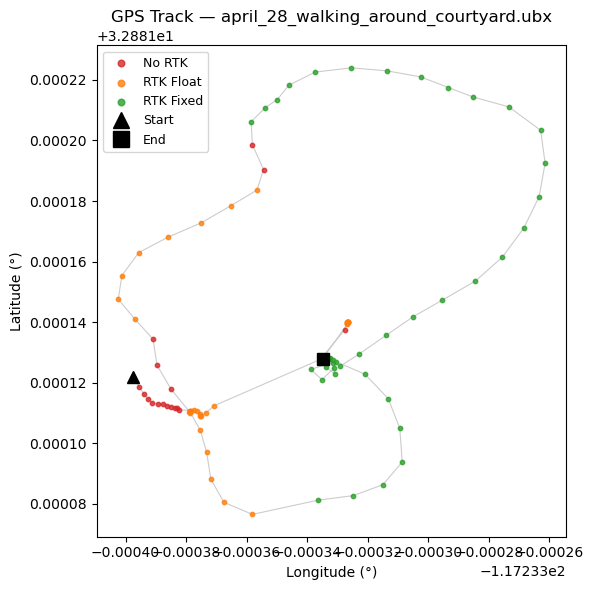

In [17]:
RTK_COLORS = {0: "#d62728", 1: "#ff7f0e", 2: "#2ca02c"}   # red / orange / green
RTK_LABELS = {0: "No RTK", 1: "RTK Float", 2: "RTK Fixed"}

fig, ax = plt.subplots(figsize=(8, 6))

# draw track line in light grey first
ax.plot(df["longitude"], df["latitude"], color="#cccccc", linewidth=0.8, zorder=1)

for sol, grp in df.groupby("carrier_solution"):
    ax.scatter(
        grp["longitude"], grp["latitude"],
        c=RTK_COLORS.get(sol, "grey"),
        label=RTK_LABELS.get(sol, str(sol)),
        s=10, zorder=2, alpha=0.8
    )

# mark start / end
ax.plot(df["longitude"].iloc[0],  df["latitude"].iloc[0],  "k^", ms=8, label="Start")
ax.plot(df["longitude"].iloc[-1], df["latitude"].iloc[-1], "ks", ms=8, label="End")

ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title(f"GPS Track — {Path(UBX_FILE).name}")
ax.legend(markerscale=1.5, fontsize=9)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 5 — Horizontal accuracy over time

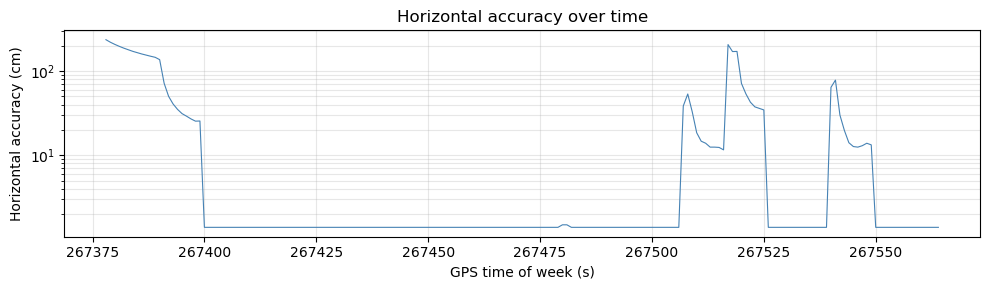

In [18]:
fig, ax = plt.subplots(figsize=(10, 3))

ax.plot(df["iTOW"] / 1000.0, df["h_acc"] * 100, linewidth=0.8, color="steelblue")
ax.set_xlabel("GPS time of week (s)")
ax.set_ylabel("Horizontal accuracy (cm)")
ax.set_title("Horizontal accuracy over time")
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## 6 — Interactive map (folium)
Points colored by RTK status. Click any point to see timestamp and accuracy.

In [19]:
if not HAS_FOLIUM:
    print("Install folium to enable this cell: pip install folium")
else:
    center = [df["latitude"].mean(), df["longitude"].mean()]
    fmap = folium.Map(location=center, zoom_start=16, tiles="OpenStreetMap")

    # track polyline
    coords = list(zip(df["latitude"], df["longitude"]))
    folium.PolyLine(coords, color="grey", weight=1.5, opacity=0.6).add_to(fmap)

    for _, row in df.iterrows():
        color = RTK_COLORS.get(int(row["carrier_solution"]), "grey")
        popup = (
            f"{row['datetime']}<br>"
            f"RTK: {RTK_LABELS.get(int(row['carrier_solution']), '?')}<br>"
            f"h_acc: {row['h_acc']*100:.1f} cm<br>"
            f"SVs: {int(row['num_sv'])}"
        )
        folium.CircleMarker(
            location=[row["latitude"], row["longitude"]],
            radius=3, color=color, fill=True, fill_opacity=0.8,
            popup=folium.Popup(popup, max_width=200)
        ).add_to(fmap)

    fmap

## 7 — 3D track plot
Lat/lon/altitude rendered in a local ENU frame (metres east/north of the track centroid),
with altitude on the vertical axis and points colored by RTK status.

filter: kept 133 / 184 epochs (rtk_only=True, require_3d=True, h_acc_max=0.05, v_acc_max=0.1)
spans after filter: E=907.75 cm  N=1589.64 cm  alt=214.30 cm


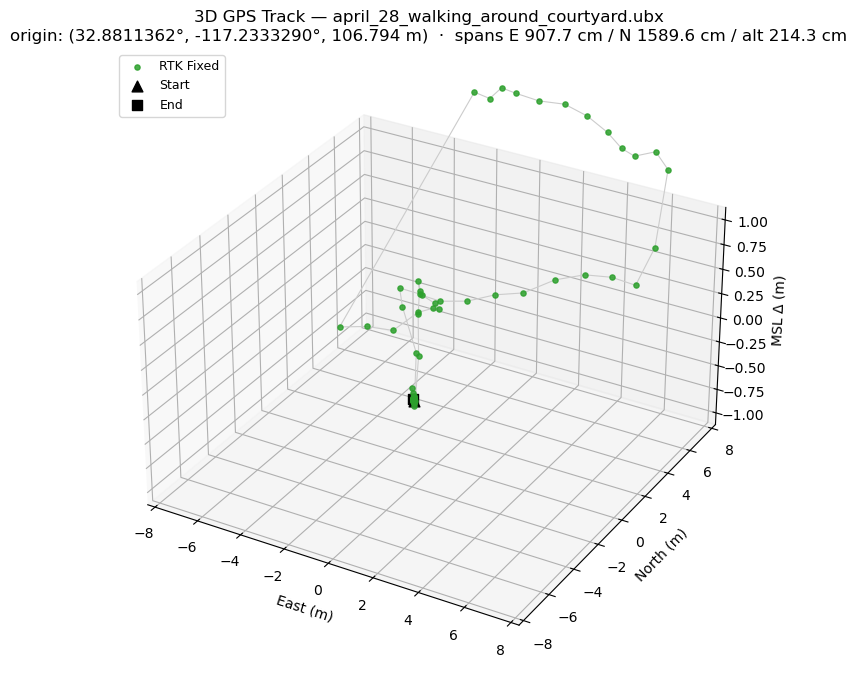

In [20]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)


def plot_track_3d(df, alt_col="hmsl",
                  rtk_only=True, require_3d=True,
                  h_acc_max=0.05, v_acc_max=0.10,
                  equal_vertical=False, pad=0.05,
                  line_color="#cccccc"):
    """Plot a 3D GPS track in a local ENU frame (metres E/N, altitude up).

    East and North share one scale so the ground track keeps its true shape.
    Altitude has an independent Z scale by default.

    Filtering
    ---------
    rtk_only=True      → keep only carrier_solution == 2 (RTK Fixed)
    require_3d=True    → keep only fix_type == 3
    h_acc_max / v_acc_max → drop epochs with reported accuracy worse than these (m)

    Set any filter to None (or rtk_only=False) to disable it.
    """
    mask = pd.Series(True, index=df.index)
    if rtk_only:
        mask &= df["carrier_solution"] == 2
    if require_3d:
        mask &= df["fix_type"] == 3
    if h_acc_max is not None:
        mask &= df["h_acc"] <= h_acc_max
    if v_acc_max is not None and alt_col in ("hmsl", "height"):
        mask &= df["v_acc"] <= v_acc_max

    d = df.loc[mask].reset_index(drop=True)
    print(f"filter: kept {len(d)} / {len(df)} epochs "
          f"(rtk_only={rtk_only}, require_3d={require_3d}, "
          f"h_acc_max={h_acc_max}, v_acc_max={v_acc_max})")
    if len(d) < 2:
        print("not enough points after filtering — relax the thresholds.")
        return None

    lat0 = d["latitude"].mean()
    lon0 = d["longitude"].mean()
    alt0 = d[alt_col].mean()

    # local tangent-plane projection (small-area flat-Earth approx)
    R = 6_378_137.0
    east  = np.radians(d["longitude"] - lon0) * R * np.cos(np.radians(lat0))
    north = np.radians(d["latitude"]  - lat0) * R
    up    = d[alt_col] - alt0

    e_span = east.max()  - east.min()
    n_span = north.max() - north.min()
    u_span = up.max()    - up.min()
    print(f"spans after filter: E={e_span*100:.2f} cm  "
          f"N={n_span*100:.2f} cm  alt={u_span*100:.2f} cm")

    h_range = max(e_span, n_span)
    h_half  = max(h_range / 2.0, 0.005) * (1 + pad)   # floor at 5 mm so a true point isn't invisible
    v_half  = max(u_span / 2.0,  0.005) * (1 + pad)
    mid_e, mid_n, mid_u = east.mean(), north.mean(), up.mean()

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot(east, north, up, color=line_color, linewidth=0.8, zorder=1)

    for sol, grp in d.groupby("carrier_solution"):
        idx = grp.index
        ax.scatter(
            east.loc[idx], north.loc[idx], up.loc[idx],
            c=RTK_COLORS.get(sol, "grey"),
            label=RTK_LABELS.get(sol, str(sol)),
            s=14, alpha=0.85, depthshade=False, zorder=2,
        )

    ax.scatter(east.iloc[0],  north.iloc[0],  up.iloc[0],
               c="k", marker="^", s=60, label="Start")
    ax.scatter(east.iloc[-1], north.iloc[-1], up.iloc[-1],
               c="k", marker="s", s=60, label="End")

    ax.set_xlim(mid_e - h_half, mid_e + h_half)
    ax.set_ylim(mid_n - h_half, mid_n + h_half)
    if equal_vertical:
        box_half = max(h_half, v_half)
        ax.set_xlim(mid_e - box_half, mid_e + box_half)
        ax.set_ylim(mid_n - box_half, mid_n + box_half)
        ax.set_zlim(mid_u - box_half, mid_u + box_half)
        ax.set_box_aspect((1, 1, 1))
    else:
        ax.set_zlim(mid_u - v_half, mid_u + v_half)
        ax.set_box_aspect((1, 1, 0.6))   # square horizontal, shorter vertical

    ax.set_xlabel("East (m)")
    ax.set_ylabel("North (m)")
    ax.set_zlabel(f"{'MSL' if alt_col == 'hmsl' else 'Ellipsoid'} Δ (m)")
    ax.set_title(
        f"3D GPS Track — {Path(UBX_FILE).name}\n"
        f"origin: ({lat0:.7f}°, {lon0:.7f}°, {alt0:.3f} m)  ·  "
        f"spans E {e_span*100:.1f} cm / N {n_span*100:.1f} cm / alt {u_span*100:.1f} cm"
    )
    ax.legend(fontsize=9, loc="upper left")

    plt.tight_layout()
    plt.show()
    return ax


plot_track_3d(df, alt_col="hmsl");

## 8 — 3D track plot with equal axes
Same plot but with a true 1:1:1 box so E/N/altitude use the same metres-per-unit.

filter: kept 133 / 184 epochs (rtk_only=True, require_3d=True, h_acc_max=0.05, v_acc_max=0.1)
spans after filter: E=907.75 cm  N=1589.64 cm  alt=214.30 cm


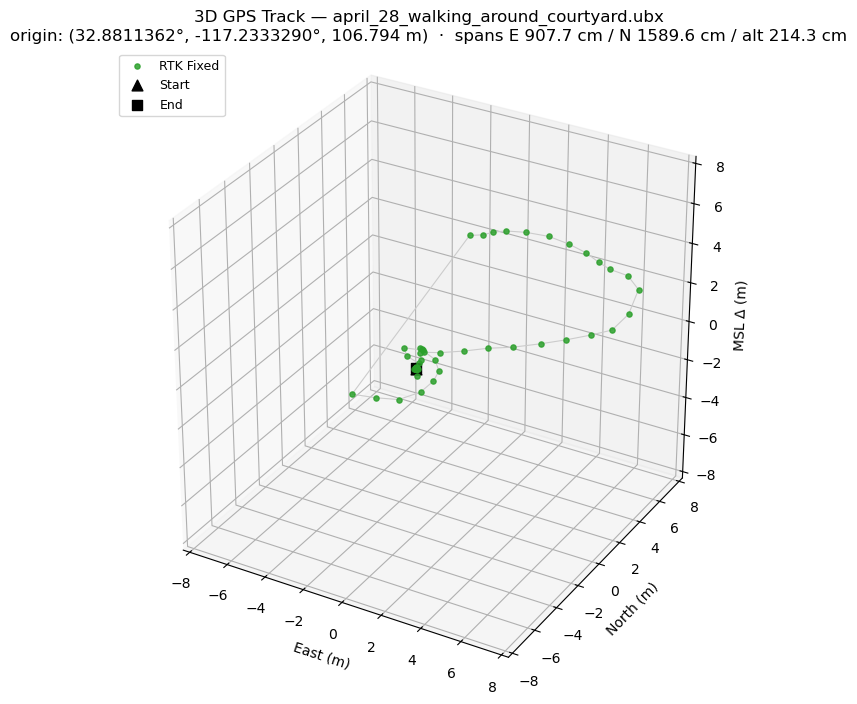

In [21]:
plot_track_3d(df, alt_col="hmsl", equal_vertical=True);